Epoch 1/5
1875/1875 [==============================] - 77s 40ms/step - loss: 0.3756 - accuracy: 0.8818
Epoch 2/5
1875/1875 [==============================] - 77s 41ms/step - loss: 0.1258 - accuracy: 0.9632
Epoch 3/5
1875/1875 [==============================] - 78s 42ms/step - loss: 0.0924 - accuracy: 0.9730
Epoch 4/5
1875/1875 [==============================] - 77s 41ms/step - loss: 0.0765 - accuracy: 0.9779
Epoch 5/5
313/313 [==============================] - 4s 11ms/step - loss: 0.0277 - accuracy: 0.9916
Loss: 0.02772570215165615
Accuracy: 0.991599977016449
1/1 [==============================] - 0s 162ms/step
File: digit6.png
The number is probably a 9


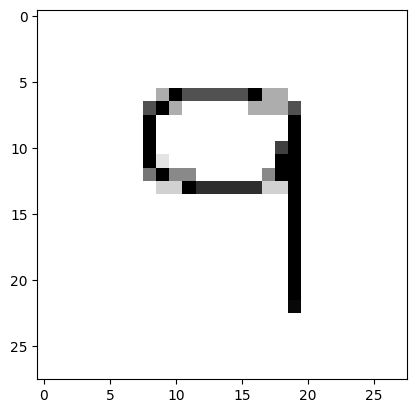

1/1 [==============================] - 0s 37ms/step
File: digit1.png
The number is probably a 7


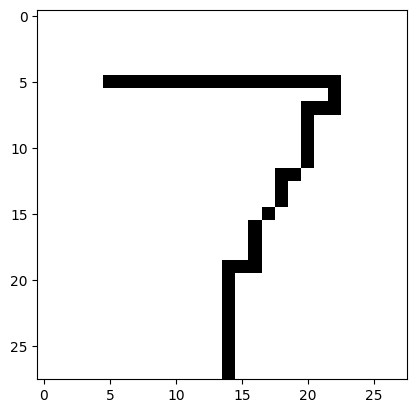

1/1 [==============================] - 0s 37ms/step
File: digit4.png
The number is probably a 3


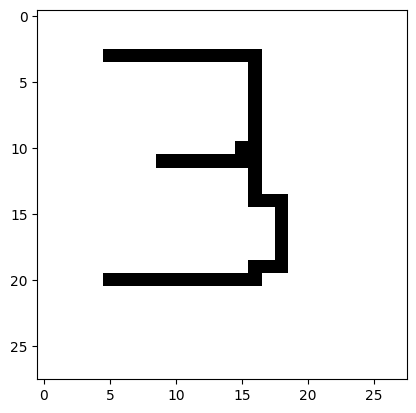

1/1 [==============================] - 0s 26ms/step
File: digit2.png
The number is probably a 8


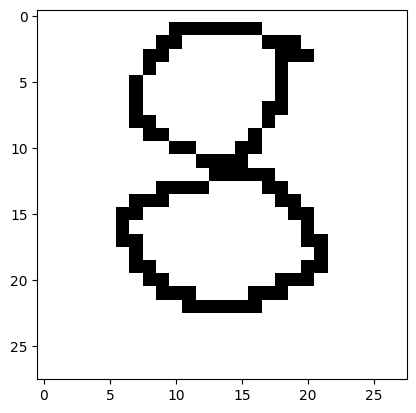

1/1 [==============================] - 0s 22ms/step
File: digit10.png
The number is probably a 1


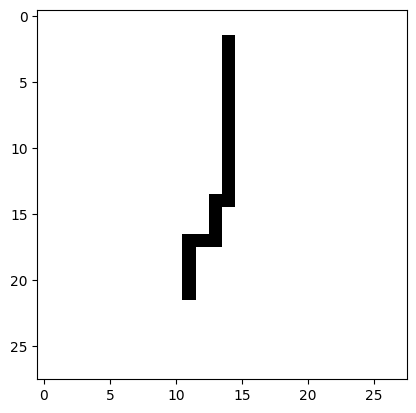

1/1 [==============================] - 0s 22ms/step
File: digit5.png
The number is probably a 1


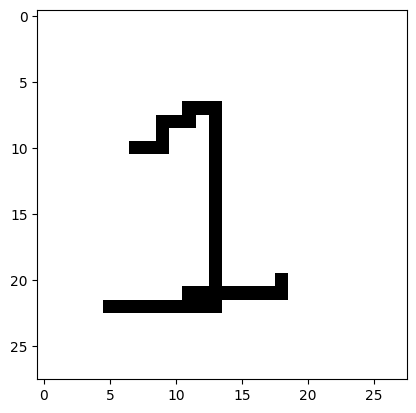

1/1 [==============================] - 0s 20ms/step
File: digit0.png
The number is probably a 7


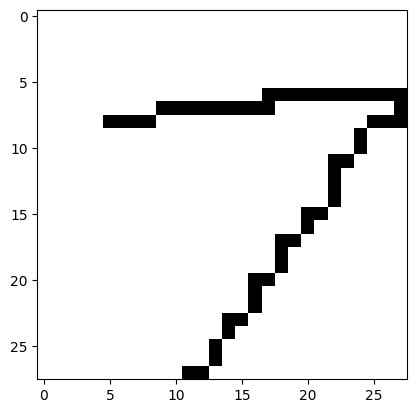

1/1 [==============================] - 0s 22ms/step
File: digit11.png
The number is probably a 5


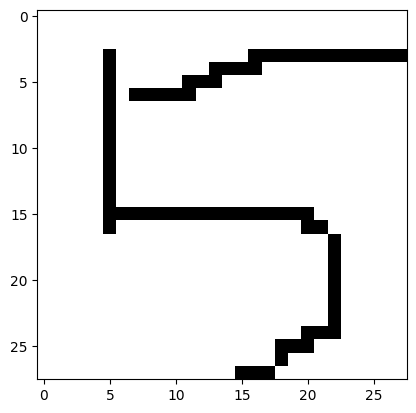

Error: Image file not found or could not be read.
Proceeding to the next one...


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape the data for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Data augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

# Define the model architecture
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(datagen.flow(x_train, y_train, batch_size=32), epochs=5)

# Save the model
model.save('handwrittenRecognition.model')

# Load the saved model
model = tf.keras.models.load_model('handwrittenRecognition.model')

# Evaluate the model on test data
loss, accuracy = model.evaluate(x_test, y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)

# Get the list of files in the directory
dir_path = "/content/drive/MyDrive/HandWritten-Digits/"
file_list = os.listdir(dir_path)

# Loop to process images
for filename in file_list:
    try:
        # Read the image
        img = cv2.imread(os.path.join(dir_path, filename), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError("Image file not found or could not be read.")

        # Preprocess the image
        img = cv2.resize(img, (28, 28))
        img = np.invert(img)  # Invert the image
        img = img / 255.0  # Normalize the pixel values to range [0, 1]
        img = np.array([img.reshape(28, 28, 1)])

        # Make predictions
        prediction = model.predict(img)
        predicted_label = np.argmax(prediction)

        # Display the image and prediction
        print("File:", filename)
        print("The number is probably a", predicted_label)
        plt.imshow(img[0].reshape(28, 28), cmap=plt.cm.binary)
        plt.show()
    except Exception as e:
        print("Error:", e)
        print("Proceeding to the next one...")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')